In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

In [4]:
# 1. Carga y Preparación del Dataset Transversal (oasis_cross-sectional.csv)
df = pd.read_csv('oasis_cross-sectional.csv')

# Selección de atributos según el informe_2
features = ['Sex', 'Age', 'Educ', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
X = df[features].copy()

# Codificación de Sexo (M=0, F=1) para scikit-learn
X['Sex'] = X['Sex'].map({'M': 0, 'F': 1})

# --- LINEAMIENTO: Binarización de CDR (2 Clases) ---
# CDR 0 -> 0 (Non demented), CDR >= 0.5 -> 1 (Demented)
y = df['CDR'].apply(lambda x: 1 if x >= 0.5 else 0)

/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['Sex']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['Sex']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Iniciando 10 validaciones independientes para Árbol de Decisión...


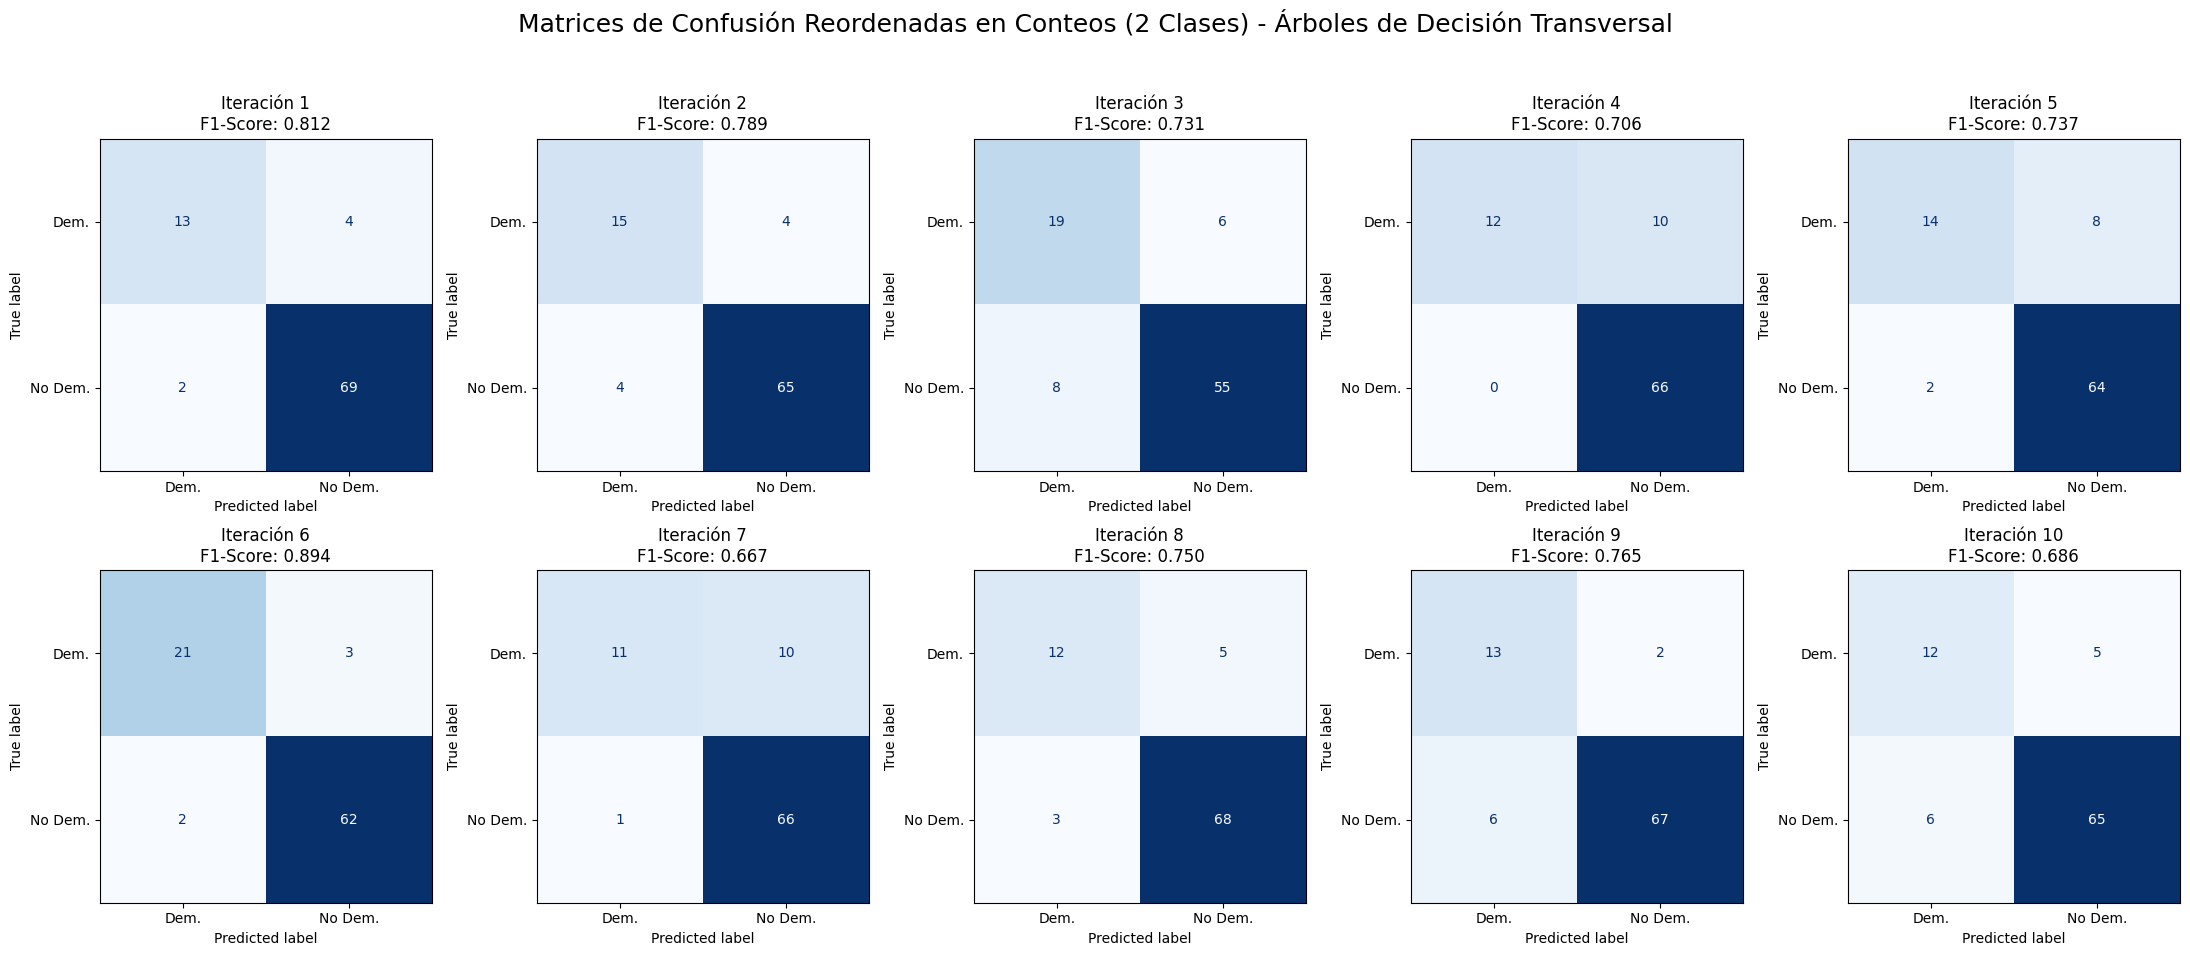

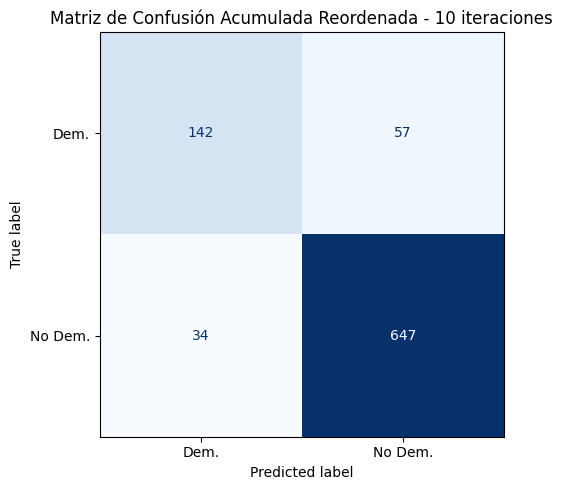


--- DESEMPEÑO FINAL ÁRBOL DE DECISIÓN ---
Métrica              | Promedio ± DE (10 iteraciones)
--------------------------------------------------
ACC                  | 0.8966 ± 0.0285
PREC                 | 0.8215 ± 0.1060
REC                  | 0.7173 ± 0.1141
F1                   | 0.7536 ± 0.0630
AUC                  | 0.9324 ± 0.0181


In [5]:
# 2. Tratamiento de Datos Faltantes (SES y Educ tienen nulos en este set)
# Usamos imputación por mediana para no perder filas valiosas [1]
imputer = SimpleImputer(strategy='median')
X_prep = imputer.fit_transform(X)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# 3. Configuración Experimental (10 Validaciones 80/20)
results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
cm_sum = np.zeros((2, 2), dtype=int)
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

print("Iniciando 10 validaciones independientes para Árbol de Decisión...")

for i in range(10):
    # Partición aleatoria única por iteración (Sección 12 de la guía) [1]
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed, y, test_size=0.2, random_state=i
    )
    
    # 4. Entrenamiento del Árbol de Decisión con Control de Complejidad
    # Usamos max_depth=4 para evitar que el árbol "memorice" el ruido (sobreajuste) [1]
    # class_weight='balanced' para compensar el desbalance natural entre clases
    dt = DecisionTreeClassifier(max_depth=4, 
                                min_samples_leaf=14,
                                random_state=42)
    dt.fit(X_train, y_train)
    
    # Predicciones
    y_pred = dt.predict(X_test)
    y_proba = dt.predict_proba(X_test)[:, 1]
    
    # 5. Registro de Métricas (Sección 13 de la guía) [1]
    results['acc'].append(accuracy_score(y_test, y_pred))
    results['prec'].append(precision_score(y_test, y_pred))
    results['rec'].append(recall_score(y_test, y_pred))
    results['f1'].append(f1_score(y_test, y_pred))
    results['auc'].append(roc_auc_score(y_test, y_proba))
    
    # 6. Generación de la Matriz de Confusión para cada iteración [Instrucción de estilo]
    cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
    cm_sum += cm
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dem.', 'No Dem.'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f"Iteración {i+1}\nF1-Score: {results['f1'][-1]:.3f}")

plt.suptitle("Matrices de Confusión Reordenadas en Conteos (2 Clases) - Árboles de Decisión Transversal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 7. Matriz de confusión acumulada sobre las 10 iteraciones
avg_cm = cm_sum
fig_avg, ax_avg = plt.subplots(figsize=(6, 5))
disp_avg = ConfusionMatrixDisplay(confusion_matrix=avg_cm, display_labels=['Dem.', 'No Dem.'])
disp_avg.plot(ax=ax_avg, cmap='Blues', colorbar=False, values_format='d')
ax_avg.set_title('Matriz de Confusión Acumulada Reordenada - 10 iteraciones')
plt.tight_layout()
plt.show()

# 8. Reporte Final de Desempeño (Media ± DE)
print("\n" + "="*50)
print(f"--- DESEMPEÑO FINAL ÁRBOL DE DECISIÓN ---")
print(f"{'Métrica':<20} | {'Promedio ± DE (10 iteraciones)':<20}")
print("-" * 50)
for m in results:
    print(f"{m.upper():<20} | {np.mean(results[m]):.4f} ± {np.std(results[m]):.4f}")
print("="*50)

Evaluando profundidades...


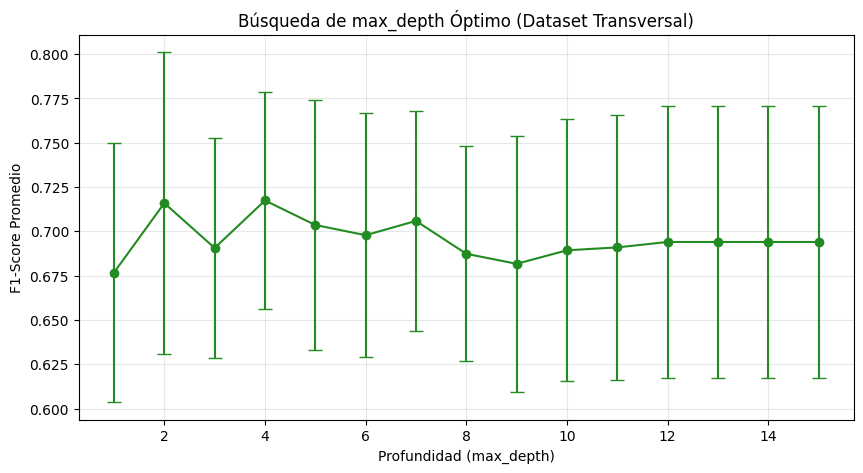

El max_depth óptimo detectado es: 4
Evaluando min_samples_leaf...


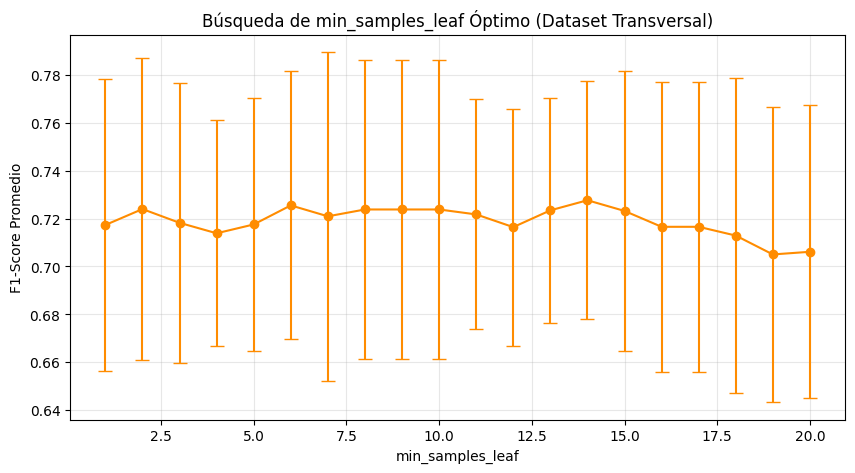

El min_samples_leaf óptimo detectado es: 14


In [6]:
depths = range(1, 16)
mean_scores = []
std_scores = []

print("Evaluando profundidades...")
for d in depths:
    iter_scores = []
    for i in range(10): # 10 Validaciones independientes 80/20
        X_train, X_test, y_train, y_test = train_test_split(
            X_prep, y, test_size=0.2, random_state=i
        )
        # Control de complejidad y balanceo de pesos
        dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=42)
        dt.fit(X_train, y_train)
        iter_scores.append(f1_score(y_test, dt.predict(X_test)))
    
    mean_scores.append(np.mean(iter_scores))
    std_scores.append(np.std(iter_scores))

# Visualización para selección
plt.figure(figsize=(10, 5))
plt.errorbar(depths, mean_scores, yerr=std_scores, fmt='-o', color='forestgreen', capsize=5)
plt.title("Búsqueda de max_depth Óptimo (Dataset Transversal)")
plt.xlabel("Profundidad (max_depth)")
plt.ylabel("F1-Score Promedio")
plt.grid(True, alpha=0.3)
plt.show()

best_depth = depths[np.argmax(mean_scores)]
print(f"El max_depth óptimo detectado es: {best_depth}")

leaf_values = range(1, 21)
leaf_scores = []
leaf_stds = []

print("Evaluando min_samples_leaf...")
for leaf in leaf_values:
    iter_scores = []
    for i in range(10):
        X_train, X_test, y_train, y_test = train_test_split(
            X_prep, y, test_size=0.2, random_state=i
        )
        dt = DecisionTreeClassifier(
            max_depth=best_depth,
            min_samples_leaf=leaf,
            class_weight='balanced',
            random_state=42,
        )
        dt.fit(X_train, y_train)
        iter_scores.append(f1_score(y_test, dt.predict(X_test)))
    leaf_scores.append(np.mean(iter_scores))
    leaf_stds.append(np.std(iter_scores))

plt.figure(figsize=(10, 5))
plt.errorbar(leaf_values, leaf_scores, yerr=leaf_stds, fmt='-o', color='darkorange', capsize=5)
plt.title("Búsqueda de min_samples_leaf Óptimo (Dataset Transversal)")
plt.xlabel("min_samples_leaf")
plt.ylabel("F1-Score Promedio")
plt.grid(True, alpha=0.3)
plt.show()

best_leaf = leaf_values[np.argmax(leaf_scores)]
print(f"El min_samples_leaf óptimo detectado es: {best_leaf}")

Evaluando profundidades...


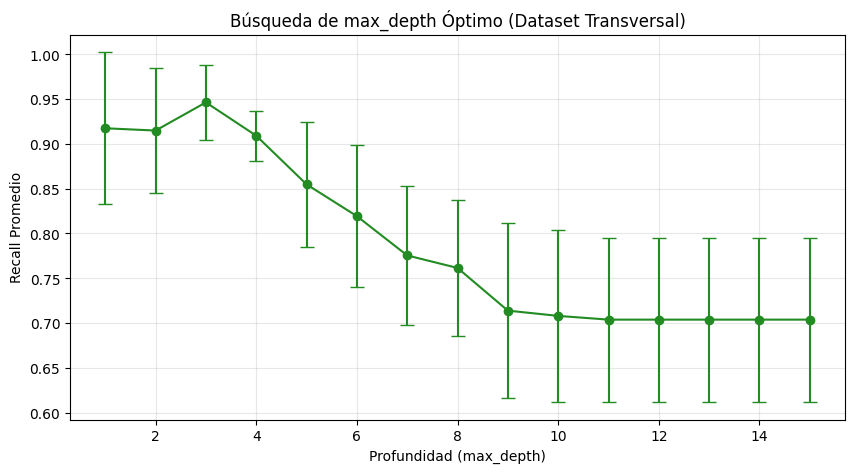

El max_depth óptimo detectado es: 3
Evaluando min_samples_leaf...


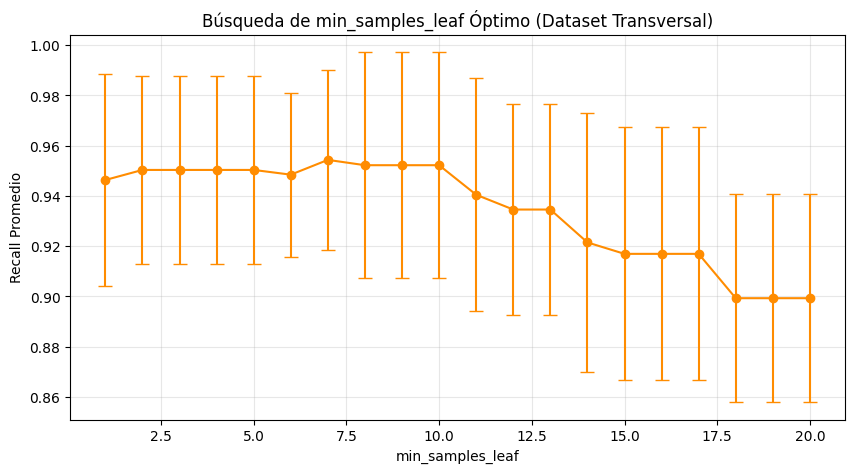

El min_samples_leaf óptimo detectado es: 7


In [7]:
depths = range(1, 16)
mean_scores = []
std_scores = []

print("Evaluando profundidades...")
for d in depths:
    iter_scores = []
    for i in range(10): # 10 Validaciones independientes 80/20
        X_train, X_test, y_train, y_test = train_test_split(
            X_prep, y, test_size=0.2, random_state=i
        )
        # Control de complejidad y balanceo de pesos
        dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=42)
        dt.fit(X_train, y_train)
        iter_scores.append(recall_score(y_test, dt.predict(X_test)))
    
    mean_scores.append(np.mean(iter_scores))
    std_scores.append(np.std(iter_scores))

# Visualización para selección
plt.figure(figsize=(10, 5))
plt.errorbar(depths, mean_scores, yerr=std_scores, fmt='-o', color='forestgreen', capsize=5)
plt.title("Búsqueda de max_depth Óptimo (Dataset Transversal)")
plt.xlabel("Profundidad (max_depth)")
plt.ylabel("Recall Promedio")
plt.grid(True, alpha=0.3)
plt.show()

best_depth = depths[np.argmax(mean_scores)]
print(f"El max_depth óptimo detectado es: {best_depth}")

leaf_values = range(1, 21)
leaf_scores = []
leaf_stds = []

print("Evaluando min_samples_leaf...")
for leaf in leaf_values:
    iter_scores = []
    for i in range(10):
        X_train, X_test, y_train, y_test = train_test_split(
            X_prep, y, test_size=0.2, random_state=i
        )
        dt = DecisionTreeClassifier(
            max_depth=best_depth,
            min_samples_leaf=leaf,
            class_weight='balanced',
            random_state=42,
        )
        dt.fit(X_train, y_train)
        iter_scores.append(recall_score(y_test, dt.predict(X_test)))
    leaf_scores.append(np.mean(iter_scores))
    leaf_stds.append(np.std(iter_scores))

plt.figure(figsize=(10, 5))
plt.errorbar(leaf_values, leaf_scores, yerr=leaf_stds, fmt='-o', color='darkorange', capsize=5)
plt.title("Búsqueda de min_samples_leaf Óptimo (Dataset Transversal)")
plt.xlabel("min_samples_leaf")
plt.ylabel("Recall Promedio")
plt.grid(True, alpha=0.3)
plt.show()

best_leaf = leaf_values[np.argmax(leaf_scores)]
print(f"El min_samples_leaf óptimo detectado es: {best_leaf}")

In [8]:
# Configuración de resultados y visualización
final_res = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

print(f"Generando evaluación final para max_depth = {best_depth} y min_samples_leaf = {best_leaf}...")

for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
        X_prep, y, test_size=0.2, random_state=i
    )
    |
    # Modelo con hiperparámetros óptimos
    model = DecisionTreeClassifier(max_depth=best_depth, 
                                   min_samples_leaf=best_leaf,
                                   class_weight='balanced', 
                                   random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Registro de métricas
    final_res['acc'].append(accuracy_score(y_test, y_pred))
    final_res['prec'].append(precision_score(y_test, y_pred))
    final_res['rec'].append(recall_score(y_test, y_pred))
    final_res['f1'].append(f1_score(y_test, y_pred))
    final_res['auc'].append(roc_auc_score(y_test, y_proba))
    
    # Grid de Matrices de Confusión por iteración
    cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dem.', 'No Dem.'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f"Iteración {i+1}\nF1: {final_res['f1'][-1]:.3f}")

plt.suptitle(f"Matrices de Confusión Reordenadas (Depth={best_depth}, Leaf={best_leaf}) - Árbol de Decisión Transversal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Reporte Estadístico Final
print("\n" + "="*55)
print(f"--- DESEMPEÑO FINAL ÁRBOL (Depth={best_depth}, Leaf={best_leaf}) ---")
print(f"{'Métrica':<25} | {'Promedio ± DE':<25}")
print("-" * 55)
for m in final_res:
    print(f"{m.upper():<25} | {np.mean(final_res[m]):.4f} ± {np.std(final_res[m]):.4f}")
print("="*55)

SyntaxError: invalid syntax (2481290278.py, line 12)

Generando evaluación final para max_depth = 4 y min_samples_leaf = 14...


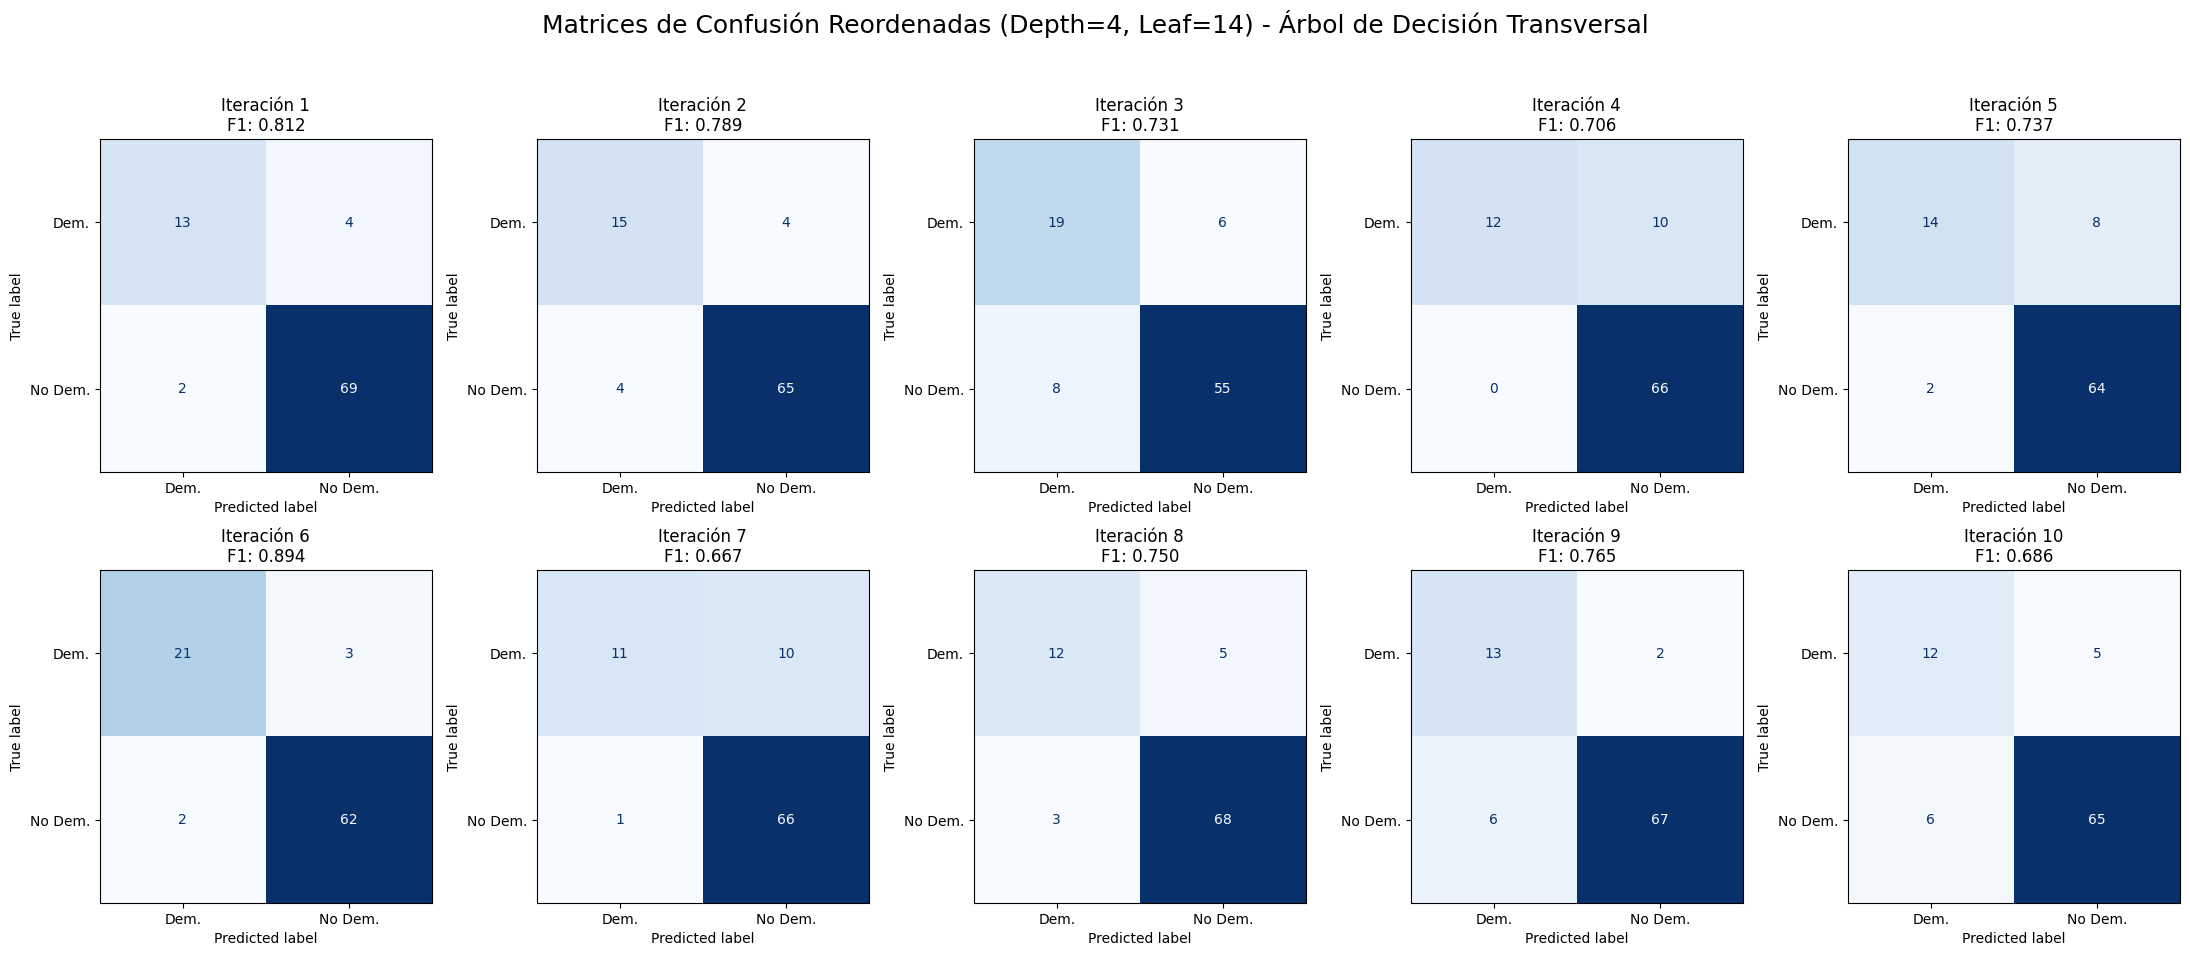


--- DESEMPEÑO FINAL ÁRBOL (Depth=4, Leaf=14) ---
Métrica                   | Promedio ± DE            
-------------------------------------------------------
ACC                       | 0.8966 ± 0.0285
PREC                      | 0.8215 ± 0.1060
REC                       | 0.7173 ± 0.1141
F1                        | 0.7536 ± 0.0630
AUC                       | 0.9324 ± 0.0181


In [ ]:
# Configuración de resultados y visualización
final_res = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

print(f"Generando evaluación final para max_depth = {best_depth} y min_samples_leaf = {best_leaf}...")

for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
        X_prep, y, test_size=0.2, random_state=i
    )
    
    # Modelo con hiperparámetros óptimos
    model = DecisionTreeClassifier(max_depth=best_depth, 
                                   min_samples_leaf=best_leaf,
                                   random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Registro de métricas
    final_res['acc'].append(accuracy_score(y_test, y_pred))
    final_res['prec'].append(precision_score(y_test, y_pred))
    final_res['rec'].append(recall_score(y_test, y_pred))
    final_res['f1'].append(f1_score(y_test, y_pred))
    final_res['auc'].append(roc_auc_score(y_test, y_proba))
    
    # Grid de Matrices de Confusión por iteración
    cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dem.', 'No Dem.'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f"Iteración {i+1}\nF1: {final_res['f1'][-1]:.3f}")

plt.suptitle(f"Matrices de Confusión Reordenadas (Depth={best_depth}, Leaf={best_leaf}) - Árbol de Decisión Transversal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Reporte Estadístico Final
print("\n" + "="*55)
print(f"--- DESEMPEÑO FINAL ÁRBOL (Depth={best_depth}, Leaf={best_leaf}) ---")
print(f"{'Métrica':<25} | {'Promedio ± DE':<25}")
print("-" * 55)
for m in final_res:
    print(f"{m.upper():<25} | {np.mean(final_res[m]):.4f} ± {np.std(final_res[m]):.4f}")
print("="*55)

Generando evaluación final para max_depth = 3 y min_samples_leaf = 7...


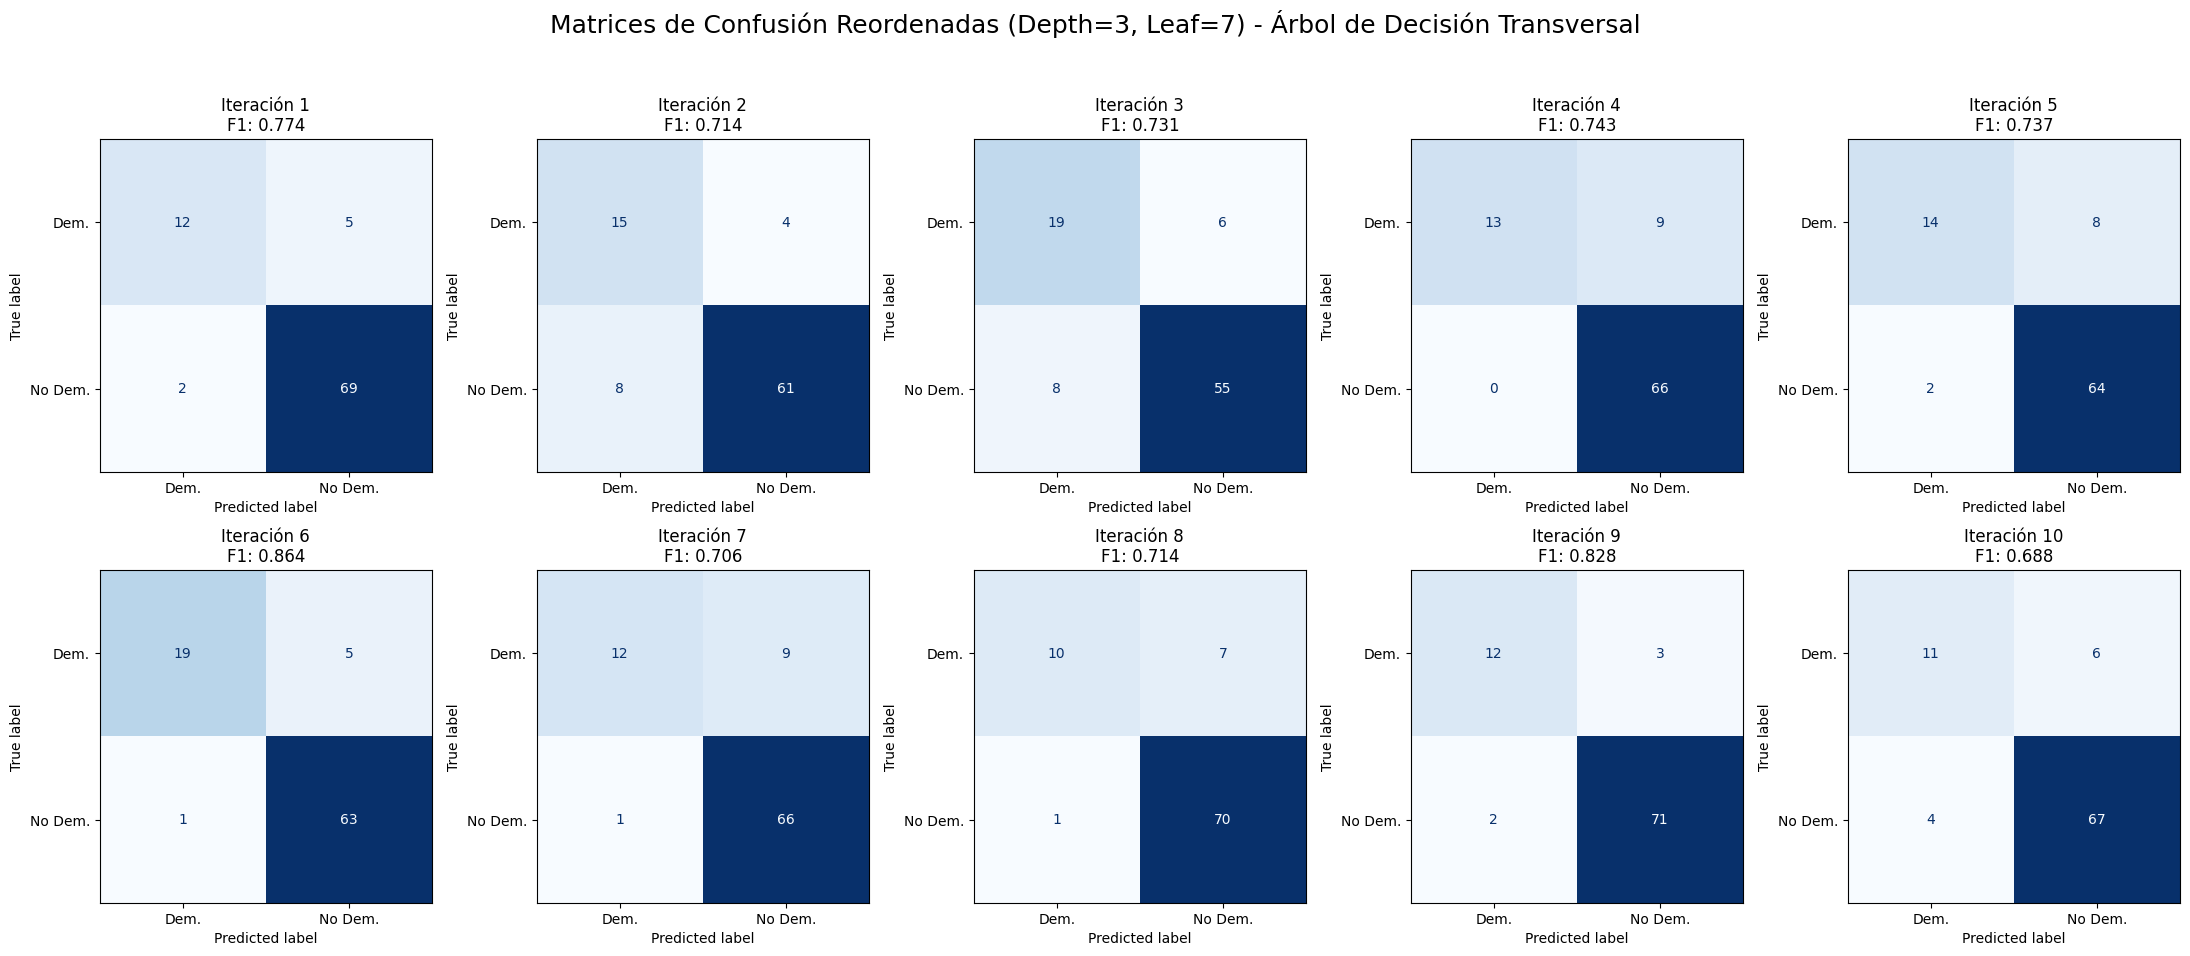


--- DESEMPEÑO FINAL ÁRBOL (Depth=3, Leaf=7) ---
Métrica                   | Promedio ± DE            
-------------------------------------------------------
ACC                       | 0.8966 ± 0.0294
PREC                      | 0.8461 ± 0.1077
REC                       | 0.6881 ± 0.0874
F1                        | 0.7498 ± 0.0534
AUC                       | 0.9212 ± 0.0253


In [11]:
# Configuración de resultados y visualización
final_res = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

print(f"Generando evaluación final para max_depth = {best_depth} y min_samples_leaf = {best_leaf}...")

for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
        X_prep, y, test_size=0.2, random_state=i
    )
    
    # Modelo con hiperparámetros óptimos
    model = DecisionTreeClassifier(max_depth=4, 
                                   min_samples_leaf=7,
                                   random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Registro de métricas
    final_res['acc'].append(accuracy_score(y_test, y_pred))
    final_res['prec'].append(precision_score(y_test, y_pred))
    final_res['rec'].append(recall_score(y_test, y_pred))
    final_res['f1'].append(f1_score(y_test, y_pred))
    final_res['auc'].append(roc_auc_score(y_test, y_proba))
    
    # Grid de Matrices de Confusión por iteración
    cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dem.', 'No Dem.'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f"Iteración {i+1}\nF1: {final_res['f1'][-1]:.3f}")

plt.suptitle(f"Matrices de Confusión Reordenadas (Depth={best_depth}, Leaf={best_leaf}) - Árbol de Decisión Transversal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Reporte Estadístico Final
print("\n" + "="*55)
print(f"--- DESEMPEÑO FINAL ÁRBOL (Depth={best_depth}, Leaf={best_leaf}) ---")
print(f"{'Métrica':<25} | {'Promedio ± DE':<25}")
print("-" * 55)
for m in final_res:
    print(f"{m.upper():<25} | {np.mean(final_res[m]):.4f} ± {np.std(final_res[m]):.4f}")
print("="*55)